In [1]:
# https://platform.olimpiada-ai.ro/en/problems/180

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/project-oroborous/obsidian_train.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/project-oroborous/obsidian_test.csv")

train.shape, test.shape

((10000, 5), (3000, 3))

In [3]:
train.head()

,id_hex,flux_energy,resonance_str,sensor_x,sensor_y
0,2E86E,17835.148887,gardsolidverianluxhelidluxlum,-30.140797,20.628435
1,A5890,20479.820172,echofailfailkzzvoidkzzbzzfailerrnu,36.334533,-21.720997
2,49392,7801.324247,aetaetidaetluzmianaetianver,-14.463592,19.667346
3,5C0D4,11359.735179,failzecho,-9.244456,32.596626
4,E1069,26632.889062,verianobsid,-0.008725,-44.631826


In [4]:
test.head()

,id_hex,flux_energy,resonance_str
0,CE15,19127.183983,verluxsolluxluzmobsverlumgardl
1,F0FD5,7915.016050,ververididluxidhelidsol
2,C1984,6336.378707,luxidluxlux
3,AA7D,2406.950952,heliang
4,64091,21238.807723,kzzxxxzzrrxxxzr


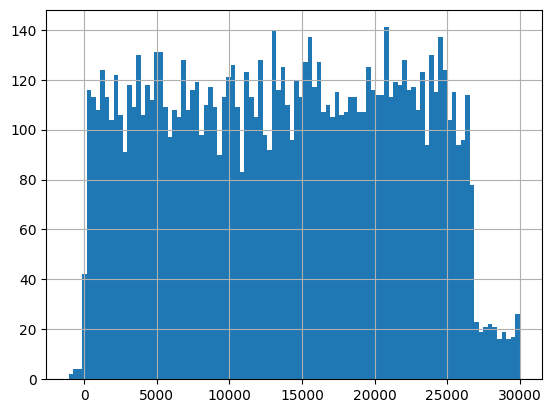

In [5]:
train['flux_energy'].hist(bins=100)
plt.show()

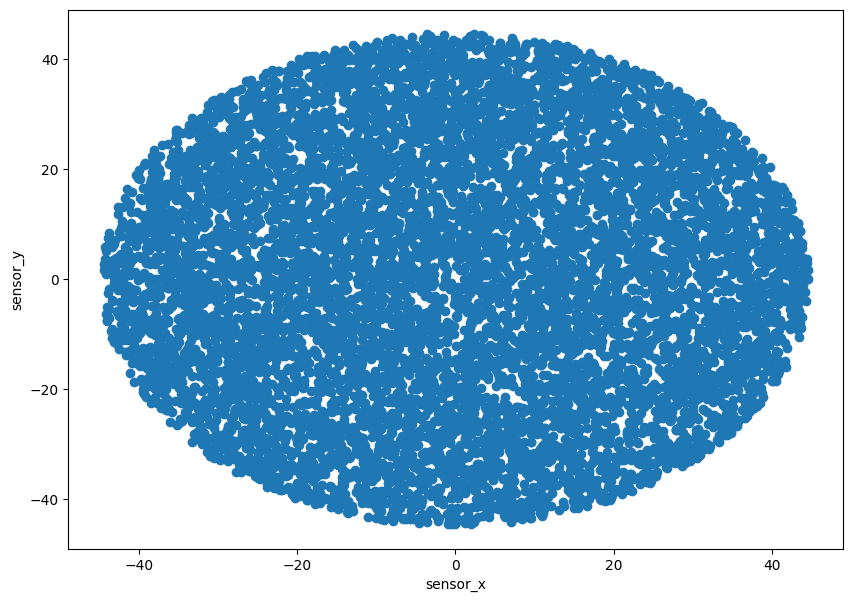

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(train['sensor_x'], train['sensor_y'])
plt.xlabel('sensor_x')
plt.ylabel('sensor_y')
plt.show()

In [7]:
fig = px.scatter_3d(
    data_frame=train,
    x='sensor_x',
    y='sensor_y',
    z='flux_energy',
)

fig.update_traces(marker=dict(size=1))

fig.show()

a 3d parabola is seen clearly

In [8]:
from sklearn.linear_model import LinearRegression, RANSACRegressor

data = pd.DataFrame({
    'x': train['sensor_x'],
    'x2': train['sensor_x'] ** 2,
    'y': train['sensor_y'],
    'y2': train['sensor_y'] ** 2,
    'xy': train['sensor_x'] * train['sensor_y'],
    'target': train['flux_energy']
})

features = ['x', 'y', 'x2', 'y2', 'xy']
target_col = 'target'

model = RANSACRegressor(estimator=LinearRegression(fit_intercept=False), min_samples=100)

model.fit(data[features], data[target_col])

data['pred'] = model.predict(data[features])

coef, intercept = model.estimator_.coef_, model.estimator_.intercept_
coef, intercept

(array([-0.88503849, -3.47221751, 13.23633717, 13.24682529, -0.05385949]), 0.0)

In [9]:
thresh = 525

temp = pd.DataFrame()

temp['x'] = train['sensor_x']
temp['y'] = train['sensor_y']
temp['x2'] = train['sensor_x'] ** 2
temp['y2'] = train['sensor_y'] ** 2
temp['xy'] = train['sensor_x'] * train['sensor_y']

mask = abs(train['flux_energy'] - model.predict(temp[features])) <= thresh

train['parabola'] = mask.astype(int)

mask.mean() 

np.float64(0.7418)

In [10]:
fig = px.scatter_3d(
    data_frame=train,
    x='sensor_x',
    y='sensor_y',
    z='flux_energy',
    color='parabola'
)

fig.update_traces(marker=dict(size=3))

fig.show()

In [11]:
target_col = 'parabola'

words_list = ['echo', 'fail', 'kzz', 'void', 'bzz', 'err', 'null', 'zrr']

In [12]:
train['no_words'] = train['resonance_str'].map(lambda x: not any([w in x for w in words_list])).astype(int)

fig = px.scatter_3d(
    data_frame=train,
    x='sensor_x',
    y='sensor_y',
    z='flux_energy',
    color='no_words'
)

fig.update_traces(marker=dict(size=3))

fig.show()

In [13]:
def go_over(text): # this function is vibe-coded
    if text is None:
        return ""
    # longest-first prevents partial matches if you ever add overlapping tokens
    tokens = sorted(words_list, key=len, reverse=True)

    out = []
    i = 0
    n = len(text)

    while i < n:
        matched = None
        for t in tokens:
            if text.startswith(t, i):
                matched = t
                break

        if matched is not None:
            out.append(matched)
            i += len(matched)
        else:
            # consume 1 char into the current "non-keyword" chunk
            ch = text[i]
            if out and (out[-1] not in tokens):
                out[-1] += ch
            else:
                out.append(ch)
            i += 1

    return " ".join(out)

def extract_features(df):
    features, text_features = ['flux_energy'], []
    
    df['text'] = df['resonance_str'].map(lambda x: go_over(x))
    features.append('text')
    text_features.append('text')

    for length in range(1, 5):
        df[f'text_{length}'] = df['resonance_str'].map(lambda x: ' '.join([x[i:i+length] for i in range(0, len(x), length)]))
        features.append(f'text_{length}')
        text_features.append(f'text_{length}')

    df['len'] = df['resonance_str'].map(lambda x: len(x))
    features.append('len')
    return features, text_features

features, text_features = extract_features(train)
features, text_features = extract_features(test)

In [14]:
train[train['parabola']==0].resonance_str.values[:20]

array(['echofailfailkzzvoidkzzbzzfailerrnu', 'failzecho',
       'voidxxxxxxnullbzzvoidzrrvoidzrrnul', 'bzzfazilerrf',
       'echozrrerrechovoidkzzvoidfailerrbzzechonul',
       'zrrkzzerrechzoechovoidbzzv', 'kzzbzzerrvoidzrrbzzbzz',
       'echozrrbzznullz', 'iangarzdlumaet',
       'iangardsolsolaetobslumhelgardlumver', 'errzrrerr', 'voidzzrrz',
       'iansolluzmsolverhe', 'kzzkzzzbz', 'kzzxxxnullvoidb',
       'bzzzrrznullbzz', 'ianhezlaetga', 'nullechoxxzxerrvoidzrr',
       'bzzechozfailxxxb', 'nullbzzznullvo'], dtype=object)

In [15]:
train[train['parabola']==1].resonance_str.values[:20]

array(['gardsolidverianluxhelidluxlum', 'aetaetidaetluzmianaetianver',
       'verianobsid', 'aetsolobsluxhelaetidluxaetianlumianversol',
       'gards', 'nullxxxechovoidxxxfailxxxzrrvoidbzzkzzvoidbzzn',
       'iangardhelaethellux', 'idaetluxhelgardobslumsolaetianh',
       'ianhelianianverid', 'aethelverlu',
       'idhelidverververianaetididhel', 'ianhe',
       'voidkzzxxxzrrzzrrxxxechofai', 'luxgardidaethelluxsolae',
       'helidgardaetaetluxaetaethelaetsolaetverhelgardh',
       'obsluxididianidia',
       'lumhelverlumobsobsvergzardgardgardlumidaetids', 'ianga', 'gardo',
       'solzidlu'], dtype=object)

In [16]:
(train['resonance_str'].map(lambda x: not any([w in x for w in words_list])).astype(int) == train['parabola']).mean()

np.float64(0.818)

In [17]:
from sklearn.metrics import matthews_corrcoef as mcc

mcc(train['parabola'], train['resonance_str'].map(lambda x: not any([w in x for w in words_list])).astype(int))

np.float64(0.5338581255471948)

In [18]:
X, y = train[features], train[target_col]

train.head()

,id_hex,flux_energy,resonance_str,sensor_x,sensor_y,parabola,no_words,text,text_1,text_2,text_3,text_4,len
0,2E86E,17835.148887,gardsolidverianluxhelidluxlum,-30.140797,20.628435,1,1,gardsolidverianluxhelidluxlum,g a r d s o l i d v e r i a n l u x h e l i d ...,ga rd so li dv er ia nl ux he li dl ux lu m,gar dso lid ver ian lux hel idl uxl um,gard soli dver ianl uxhe lidl uxlu m,29
1,A5890,20479.820172,echofailfailkzzvoidkzzbzzfailerrnu,36.334533,-21.720997,0,0,echo fail fail kzz void kzz bzz fail err nu,e c h o f a i l f a i l k z z v o i d k z z b ...,ec ho fa il fa il kz zv oi dk zz bz zf ai le r...,ech ofa ilf ail kzz voi dkz zbz zfa ile rrn u,echo fail fail kzzv oidk zzbz zfai lerr nu,34
2,49392,7801.324247,aetaetidaetluzmianaetianver,-14.463592,19.667346,1,1,aetaetidaetluzmianaetianver,a e t a e t i d a e t l u z m i a n a e t i a ...,ae ta et id ae tl uz mi an ae ti an ve r,aet aet ida etl uzm ian aet ian ver,aeta etid aetl uzmi anae tian ver,27
3,5C0D4,11359.735179,failzecho,-9.244456,32.596626,0,0,fail z echo,f a i l z e c h o,fa il ze ch o,fai lze cho,fail zech o,9
4,E1069,26632.889062,verianobsid,-0.008725,-44.631826,1,1,verianobsid,v e r i a n o b s i d,ve ri an ob si d,ver ian obs id,veri anob sid,11


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train.shape, X_valid.shape

((9000, 7), (1000, 7))

In [20]:
from catboost import Pool

train_pool = Pool(X_train, y_train, text_features=text_features)
valid_pool = Pool(X_valid, y_valid, text_features=text_features)

In [21]:
from catboost import CatBoostClassifier

params = {
    'iterations': 100,
    'loss_function': 'CrossEntropy',
    'eval_metric': 'MCC',
    'metric_period': 10,
    'random_state': 42,
    'max_depth': 2,
    'learning_rate': 0.14
}

model = CatBoostClassifier(**params)

model.fit(train_pool, eval_set=valid_pool)

0:	learn: 0.6103635	test: 0.5989427	best: 0.5989427 (0)	total: 88.7ms	remaining: 8.78s
10:	learn: 0.6121036	test: 0.6020789	best: 0.6020789 (10)	total: 376ms	remaining: 3.04s
20:	learn: 0.6224015	test: 0.6097036	best: 0.6097036 (20)	total: 642ms	remaining: 2.41s
30:	learn: 0.6297998	test: 0.6284568	best: 0.6284568 (30)	total: 895ms	remaining: 1.99s
40:	learn: 0.6249642	test: 0.6284568	best: 0.6284568 (30)	total: 1.14s	remaining: 1.65s
50:	learn: 0.6316573	test: 0.6284568	best: 0.6284568 (30)	total: 1.4s	remaining: 1.34s
60:	learn: 0.6332701	test: 0.6378100	best: 0.6378100 (60)	total: 1.64s	remaining: 1.05s
70:	learn: 0.6326647	test: 0.6378100	best: 0.6378100 (60)	total: 1.88s	remaining: 768ms
80:	learn: 0.6326647	test: 0.6378100	best: 0.6378100 (60)	total: 2.12s	remaining: 498ms
90:	learn: 0.6326647	test: 0.6378100	best: 0.6378100 (60)	total: 2.37s	remaining: 234ms
99:	learn: 0.6325080	test: 0.6378100	best: 0.6378100 (60)	total: 2.59s	remaining: 0us

bestTest = 0.6378099667
bestIterati

In [22]:
from sklearn.metrics import matthews_corrcoef as mcc

score = mcc(y_valid, model.predict(X_valid))

print(f'Score: {score:.5f}')

Score: 0.63781


In [23]:
y_pred = model.predict(test[features])

subm = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': test['id_hex'],
    'answer': y_pred
})

subm.to_csv("submission.csv", index=False)

subm.head()

,subtaskID,datapointID,answer
0,1,CE15,0
1,1,F0FD5,1
2,1,C1984,1
3,1,AA7D,1
4,1,64091,0
